In [ ]:

pip install numpy matplotlib scikit-learn datasets ipykernel

   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   - -------------------------------------- 1.3/27.5 MB 6.9 MB/s eta 0:00:04
   --- ------------------------------------ 2.6/27.5 MB 6.7 MB/s eta 0:00:04
   ------ --------------------------------- 4.5/27.5 MB 7.2 MB/s eta 0:00:04
   ------- -------------------------------- 5.5/27.5 MB 7.1 MB/s eta 0:00:04
   ---------- ----------------------------- 7.3/27.5 MB 7.2 MB/s eta 0:00:03
   ------------- -------------------------- 9.2/27.5 MB 7.4 MB/s eta 0:00:03
   ------------------- -------------------- 13.1/27.5 MB 8.9 MB/s eta 0:00:02
   ---------------------------- ----------- 19.4/27.5 MB 11.6 MB/s eta 0:00:01
   --------------------------------- ------ 23.3/27.5 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------- 27.5/27.5 MB 13.3 MB/s  0:00:02

   -- -------------------------------------  1/16 [urllib3]
   -- -------------------------------------  1/16 [urllib3]
   -- -----------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


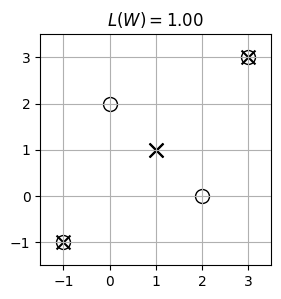

In [ ]:
import numpy as np; import matplotlib.pyplot as plt
X = np.array([ [-1, -1], [0, 2], [2, 0], [3, 3] ]); N = len(X);
K = 1; _, _, Vt = np.linalg.svd(X - X.mean(0)); W = Vt[:K, :].T; Z = X @ W; hX = Z @ W.T
L = np.square(X - hX).sum(axis=1).mean()
fig, ax = plt.subplots(figsize=(3, 3)); ax.set_aspect("equal")
plt.axis([-1.5, 3.5, -1.5, 3.5]); plt.grid(True); ax.set_title(f'$L(W)={L:.2f}$')
plt.scatter(*X.T, facecolor='white', edgecolor='k', s=100)
plt.scatter(*hX.T, facecolor='black', s=100, marker='x');

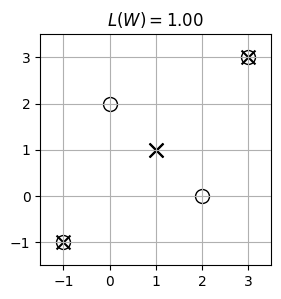

In [ ]:
import numpy as np; import matplotlib.pyplot as plt; from sklearn.decomposition import PCA
X = np.array([ [-1, -1], [0, 2], [2, 0], [3, 3] ]); N = len(X)
K = 1; pca = PCA(n_components=K).fit(X - X.mean(0));
Z = pca.transform(X)
hX = pca.inverse_transform(Z); 
L = np.square(X - hX).sum(axis=1).mean()
fig, ax = plt.subplots(figsize=(3, 3)); ax.set_aspect("equal")
plt.axis([-1.5, 3.5, -1.5, 3.5]); plt.grid(True); ax.set_title(f'$L(W)={L:.2f}$')
plt.scatter(*X.T, facecolor='white', edgecolor='k', s=100)
plt.scatter(*hX.T, facecolor='black', s=100, marker='x');


In [ ]:
import numpy as np; 
import datasets
ds = datasets.load_dataset("ylecun/mnist").with_format("numpy"); ds

c:\Users\2005p\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\2005p\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:121: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\2005p\.cache\huggingface\hub\datasets--ylecun--mnist. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administr

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [ ]:
train0 = ds['train'][0]
train0['image'].shape, train0['image'].dtype, train0['label']


((28, 28), dtype('uint8'), np.int64(5))

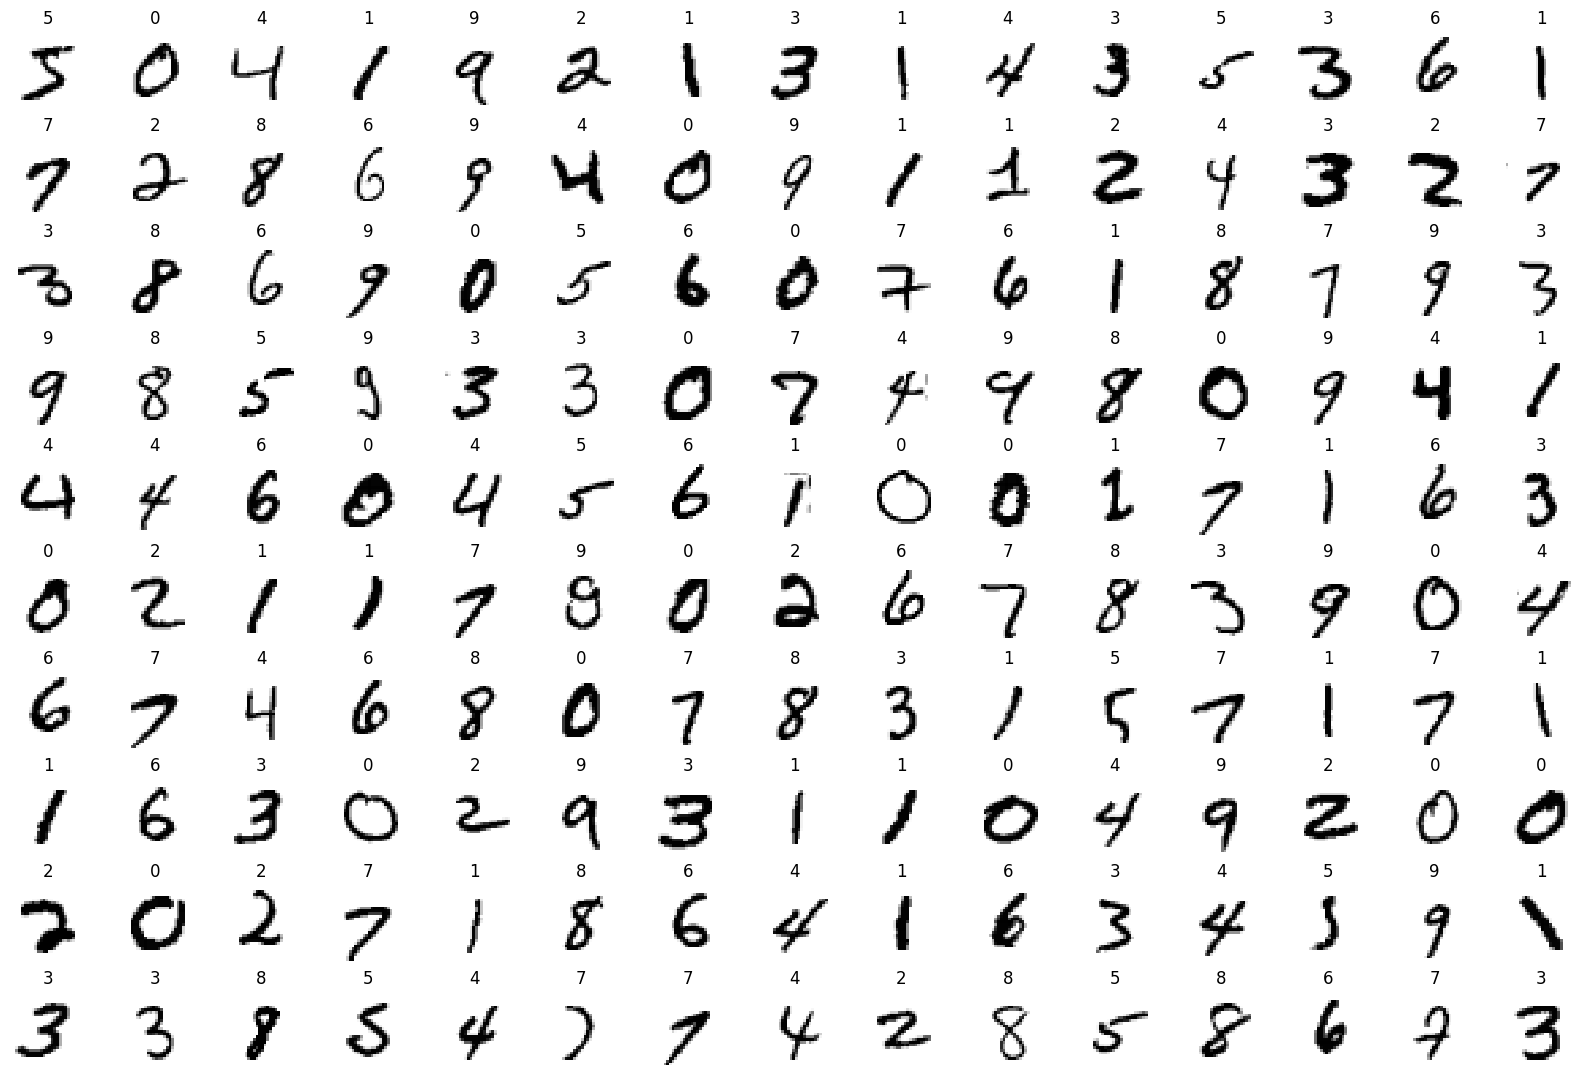

In [ ]:
import matplotlib.pyplot as plt; nrows = 10; ncols = 15; N = nrows * ncols
_, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 16*nrows/ncols), constrained_layout=True)
for ax, x, y in zip(axs.flat, ds['train'][:N]['image'], ds['train'][:N]['label']):
 ax.set_axis_off(); ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none"); ax.set_title(y)

In [ ]:
import numpy as np; import datasets
ds = datasets.load_dataset("ylecun/mnist").with_format("numpy")
X_train = ds['train'][:]['image'].astype(np.float32).reshape(-1, 28*28) / 255.
y_train = ds['train'][:]['label'].astype(np.uint8)
X_test = ds['test'][:]['image'].astype(np.float32).reshape(-1, 28*28) / 255.
y_test = ds['test'][:]['label'].astype(np.uint8)


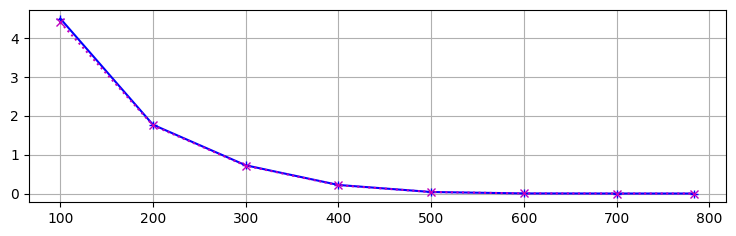

In [ ]:
import matplotlib.pyplot as plt; from sklearn.decomposition import PCA
max_K = np.min(X_train.shape); pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train); Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
L_train = np.empty_like(Ks, dtype=float); L_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
 Z_train_K = Z_train.copy(); Z_train_K[:, K:] = 0.0; hX_train = pca.inverse_transform(Z_train_K)
 L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()
 Z_test_K = Z_test.copy(); Z_test_K[:, K:] = 0.0; hX_test = pca.inverse_transform(Z_test_K)
 L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()
plt.figure(figsize=(9, 2.5)); plt.grid(True); plt.plot(Ks, L_train, '+-b', Ks, L_test, 'x:m');

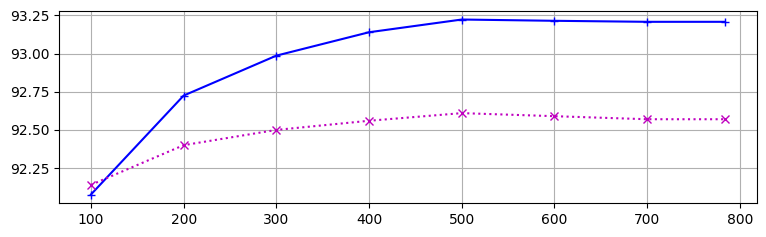

In [ ]:
from sklearn.linear_model import LogisticRegression
max_K = np.min(X_train.shape); pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train); Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
acc_train = np.empty_like(Ks, dtype=float); acc_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
 clf = LogisticRegression(C=0.1, max_iter=200).fit(Z_train[:, :K], y_train)
 acc_train[i] = clf.score(Z_train[:, :K], y_train)
 acc_test[i] = clf.score(Z_test[:, :K], y_test)
plt.figure(figsize=(9, 2.5)); plt.grid(True)
plt.plot(Ks, 100. * acc_train, '+-b', Ks, 100. * acc_test, 'x:m');

In [2]:
import numpy as np; import datasets
ds = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format("numpy")
X_train = ds['train'][:]['image'].astype(np.float32).reshape(-1, 28*28) / 255.
y_train = ds['train'][:]['label'].astype(np.uint8)
X_test = ds['test'][:]['image'].astype(np.float32).reshape(-1, 28*28) / 255.
y_test = ds['test'][:]['label'].astype(np.uint8)
labels = ("T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot")

c:\Users\2005p\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


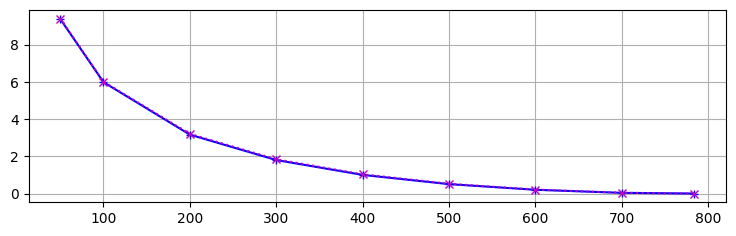

In [3]:
import matplotlib.pyplot as plt; from sklearn.decomposition import PCA
max_K = np.min(X_train.shape); pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train); Z_test = pca.transform(X_test)
Ks = np.array([50, 100, 200, 300, 400, 500, 600, 700, max_K])
L_train = np.empty_like(Ks, dtype=float); L_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
 Z_train_K = Z_train.copy(); Z_train_K[:, K:] = 0.0; hX_train = pca.inverse_transform(Z_train_K)
 L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()
 Z_test_K = Z_test.copy(); Z_test_K[:, K:] = 0.0; hX_test = pca.inverse_transform(Z_test_K)
 L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()
plt.figure(figsize=(9, 2.5)); plt.grid(True); plt.plot(Ks, L_train, '+-b', Ks, L_test, 'x:m');


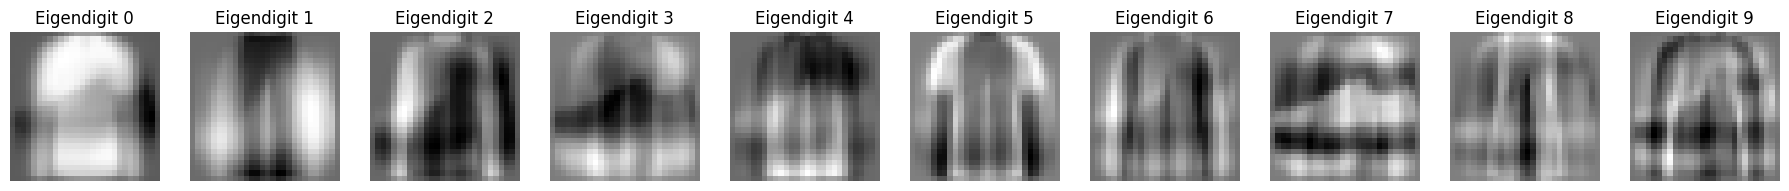

In [4]:
K = 600; pca = PCA(n_components=K).fit(X_train); nrows, ncols = 1, 10
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 18*nrows/ncols), constrained_layout=True)
for i in range(min(K, nrows * ncols)):
 ax = axs.flat[i]; ax.set_axis_off(); ax.set_title(f"Eigendigit {i}")
 ax.imshow(pca.components_[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")

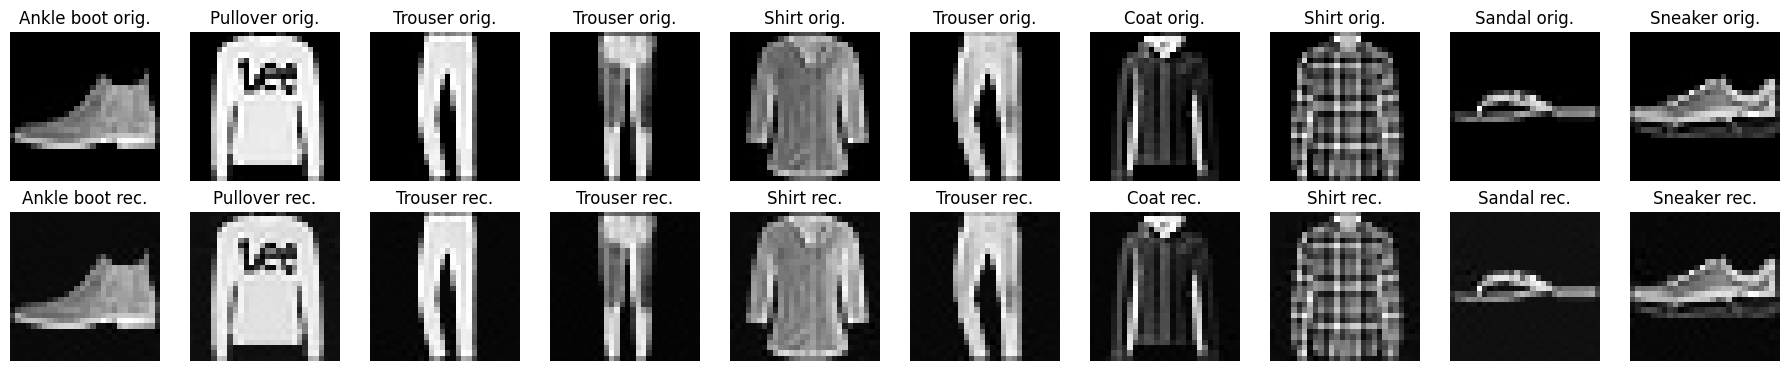

In [5]:
ncols = 10; Z_test = pca.transform(X_test[:ncols]); hX_test = pca.inverse_transform(Z_test)
fig, axs = plt.subplots(nrows=2, ncols=10, figsize=(18, 18*2/ncols), constrained_layout=True)
for i in range(ncols):
 ax = axs.flat[i]; ax.set_axis_off(); ax.set_title(f"{labels[y_test[i]]} orig.")
 ax.imshow(X_test[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")
 ax = axs.flat[ncols + i]; ax.set_axis_off(); ax.set_title(f"{labels[y_test[i]]} rec.")
 ax.imshow(hX_test[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")


c:\Users\2005p\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\2005p\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://sciki

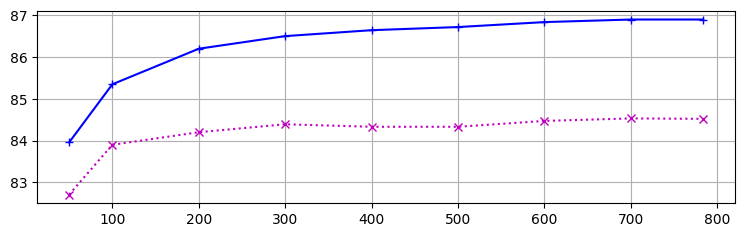

In [6]:
from sklearn.linear_model import LogisticRegression
max_K = np.min(X_train.shape); pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train); Z_test = pca.transform(X_test)
Ks = np.array([50, 100, 200, 300, 400, 500, 600, 700, max_K])
acc_train = np.empty_like(Ks, dtype=float); acc_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
 clf = LogisticRegression(C=0.05, max_iter=200).fit(Z_train[:, :K], y_train)
 acc_train[i] = clf.score(Z_train[:, :K], y_train)
 acc_test[i] = clf.score(Z_test[:, :K], y_test)
plt.figure(figsize=(9, 2.5)); plt.grid(True)
plt.plot(Ks, 100. * acc_train, '+-b', Ks, 100. * acc_test, 'x:m');